# House Price Prediction Using Machine Learning

## Introduction

This project aims to predict house prices using machine learning techniques based on housing features such as overall quality, living area, garage capacity, and basement area.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [2]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Exploratory Data Analysis (EDA)

In [3]:
df.shape

(1460, 81)

In [4]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

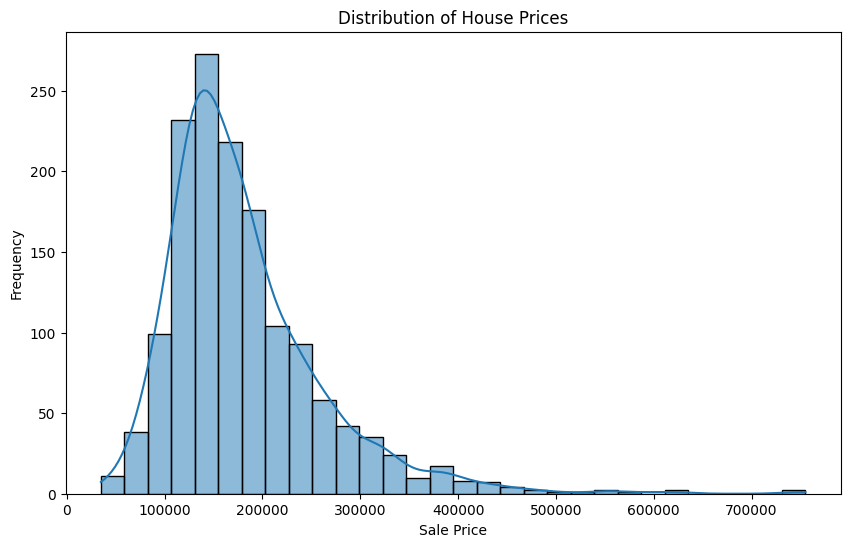

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

In [10]:
correlation = df.corr(numeric_only=True)

correlation['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


## Data Cleaning

In [11]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

In [12]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


## Feature Selection

In [13]:
X = df[['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']]

y = df['SalePrice']

## Data Splitting

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Model Training

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [16]:
predictions = model.predict(X_test)

In [17]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

## Model Evaluation

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = mse ** 0.5

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 25284.80968862931
MSE: 1598354833.0864484
RMSE: 39979.43012458342
R2 Score: 0.7916184018889857


In [20]:
dt_mae = mean_absolute_error(y_test, dt_predictions)

dt_mse = mean_squared_error(y_test, dt_predictions)

dt_rmse = dt_mse ** 0.5

dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree MSE:", dt_mse)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R2 Score:", dt_r2)

Decision Tree MAE: 26125.124429223746
Decision Tree MSE: 1492170626.9433029
Decision Tree RMSE: 38628.62445057166
Decision Tree R2 Score: 0.8054619077940736


In [21]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = rf_mse ** 0.5

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 20133.95993421153
Random Forest MSE: 938980459.6390378
Random Forest RMSE: 30642.788052640346
Random Forest R2 Score: 0.8775827214807097


In [31]:
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE': [
        mae,
        dt_mae,
        rf_mae
    ],

    'RMSE': [
        rmse,
        dt_rmse,
        rf_rmse
    ],

    'R2 Score': [
        r2,
        dt_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,25284.809689,39979.430125,0.791618
1,Decision Tree,26125.124429,38628.624451,0.805462
2,Random Forest,20133.959934,30642.788053,0.877583


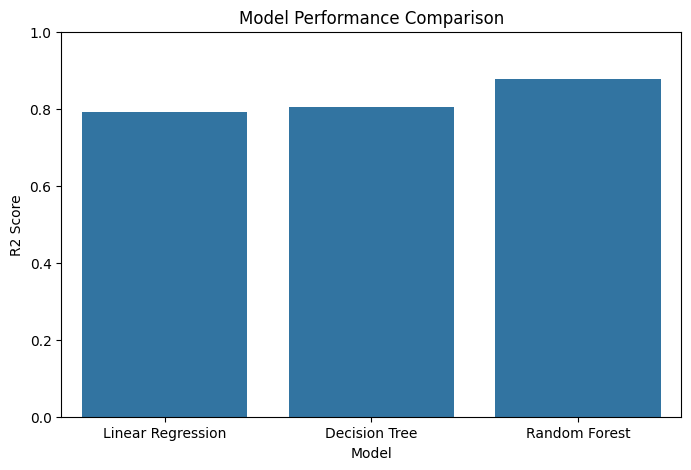

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=model_results
)

plt.title("Model Performance Comparison")

plt.ylim(0,1)

plt.show()

## Feature Importance

In [22]:
importance = rf_model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

       Feature  Importance
0  OverallQual    0.586915
1    GrLivArea    0.208590
4  TotalBsmtSF    0.116505
3   GarageArea    0.060801
2   GarageCars    0.027189


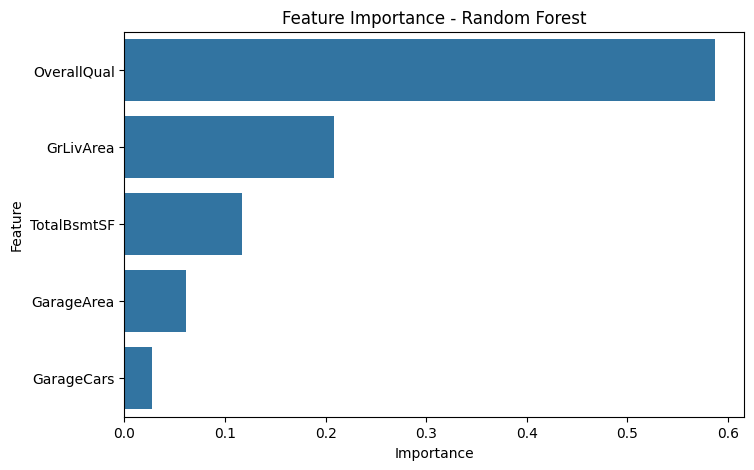

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title("Feature Importance - Random Forest")

plt.show()

## Prediction System

In [39]:
new_house1 = [[8, 2500, 2, 600, 1200]]

In [40]:
predicted_price = rf_model.predict(new_house1)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 290891.68


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [41]:
new_house2 = [[5, 1400, 1, 300, 800]]

In [42]:
predicted_price = rf_model.predict(new_house2)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 132414.04


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [44]:
new_house3 = [[10, 4000, 4, 1000, 2000]]

In [47]:
predicted_price = rf_model.predict(new_house3)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 566582.76


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [49]:
new_house1 = pd.DataFrame({
    'OverallQual': [8],
    'GrLivArea': [2500],
    'GarageCars': [2],
    'GarageArea': [600],
    'TotalBsmtSF': [1200]
})

predicted_price = rf_model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 290891.68


In [50]:
new_houses = pd.DataFrame({
    'OverallQual': [8, 5, 10],
    'GrLivArea': [2500, 1400, 4000],
    'GarageCars': [2, 1, 4],
    'GarageArea': [600, 300, 1000],
    'TotalBsmtSF': [1200, 800, 2000]
})

predicted_prices = rf_model.predict(new_houses)

predicted_prices

array([290891.68, 132414.04, 566582.76])

## Conclusion

This project successfully developed a machine learning model for predicting house prices using selected housing features. The dataset was cleaned, analyzed, and visualized before training different regression models.

Three models were tested: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. The Random Forest Regressor performed best with the highest R² score and the lowest prediction error.

The final model was also used to predict the price of a new house, showing that the system can estimate house prices based on features such as overall quality, living area, garage capacity, garage area, and basement size.